Columns in dataset: ['Temperature (°C)', 'Ice Cream Sales (units)']


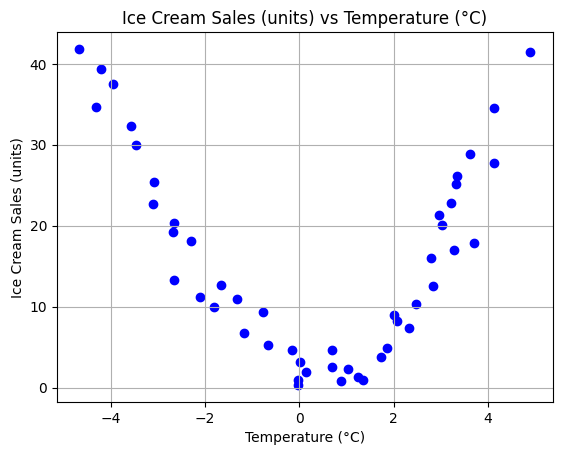

R2 Score: 0.9367
Mean Squared Error: 9.3272


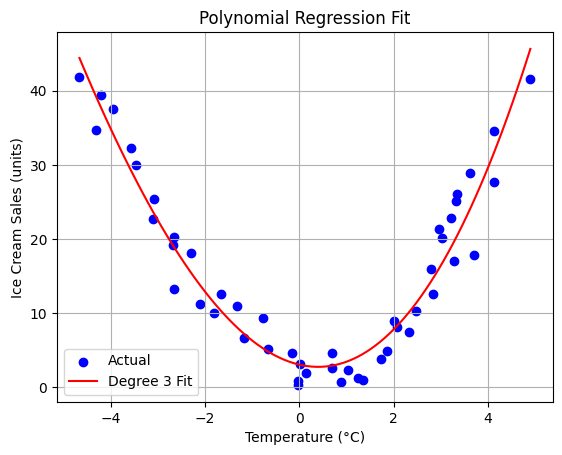

Model and transformer saved successfully.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# Load dataset
data = pd.read_csv('../data/Ice_cream selling data.csv')

# Check columns
print("Columns in dataset:", data.columns.tolist())

# Use exact column names
feature_col = "Temperature (°C)"
target_col = "Ice Cream Sales (units)"

# Select features and target
X = data[[feature_col]].values
y = data[target_col].values

# Visualize data
plt.scatter(X, y, color='blue')
plt.title(f'{target_col} vs {feature_col}')
plt.xlabel(feature_col)
plt.ylabel(target_col)
plt.grid(True)
plt.show()

# Create polynomial features
degree = 3
poly = PolynomialFeatures(degree=degree)
X_poly = poly.fit_transform(X)

# Train model
model = LinearRegression()
model.fit(X_poly, y)

# Predict on training data
y_pred = model.predict(X_poly)

# Evaluate
print(f"R2 Score: {r2_score(y, y_pred):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y, y_pred):.4f}")

# Plot fit curve
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
y_range_pred = model.predict(X_range_poly)

plt.scatter(X, y, color='blue', label='Actual')
plt.plot(X_range, y_range_pred, color='red', label=f'Degree {degree} Fit')
plt.xlabel(feature_col)
plt.ylabel(target_col)
plt.legend()
plt.grid(True)
plt.title('Polynomial Regression Fit')
plt.show()

# Save model and transformer
joblib.dump(model, '../model/polynomial_model.pkl')
joblib.dump(poly, '../model/poly_features.pkl')
print("Model and transformer saved successfully.")


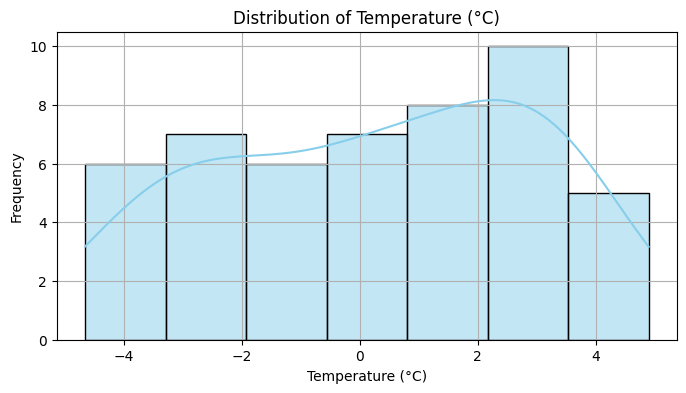

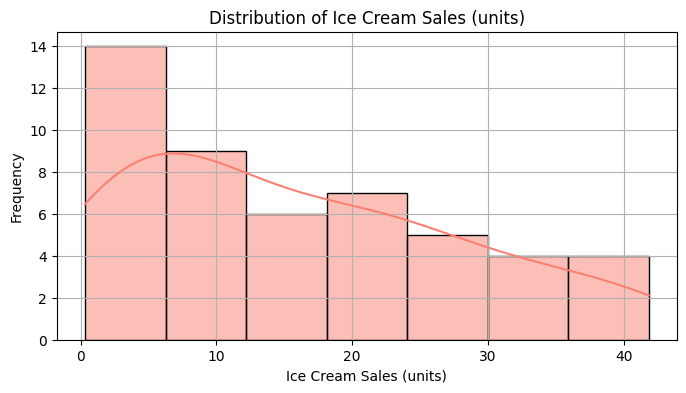

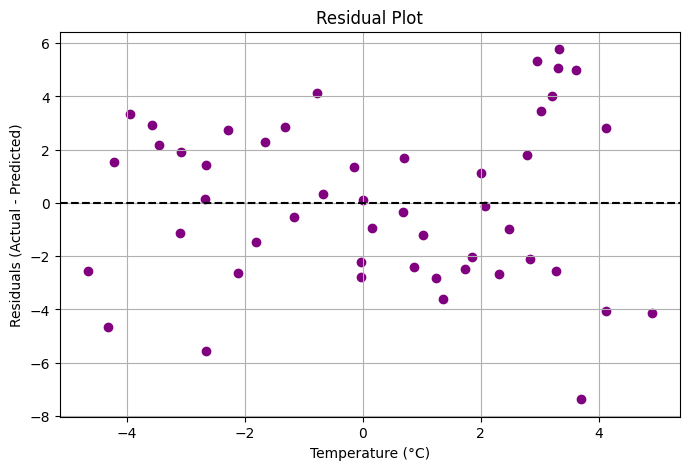

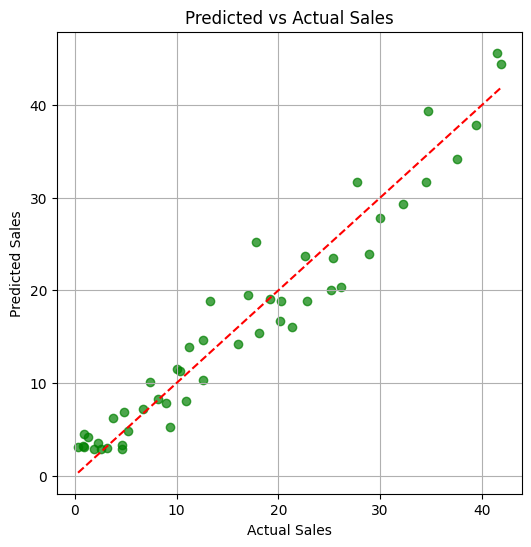

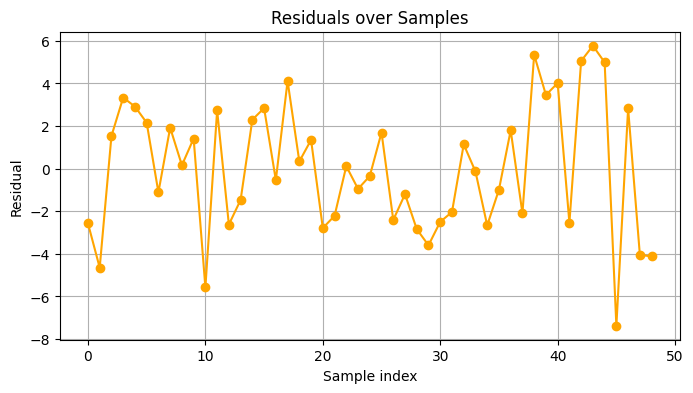

In [ ]:
import seaborn as sns

# 1. Histogram of Temperature
plt.figure(figsize=(8,4))
sns.histplot(data[feature_col], kde=True, color='skyblue')
plt.title('Distribution of Temperature (°C)')
plt.xlabel(feature_col)
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# 2. Histogram of Ice Cream Sales
plt.figure(figsize=(8,4))
sns.histplot(data[target_col], kde=True, color='salmon')
plt.title('Distribution of Ice Cream Sales (units)')
plt.xlabel(target_col)
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# 3. Residuals = Actual - Predicted
residuals = y - y_pred

plt.figure(figsize=(8,5))
plt.scatter(X, residuals, color='purple')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residual Plot')
plt.xlabel(feature_col)
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True)
plt.show()

# 4. Predicted vs Actual scatter plot
plt.figure(figsize=(6,6))
plt.scatter(y, y_pred, color='green', alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  
plt.title('Predicted vs Actual Sales')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.grid(True)
plt.show()

# 5. Residuals over ordered samples (to check patterns)
plt.figure(figsize=(8,4))
plt.plot(residuals, marker='o', linestyle='-', color='orange')
plt.title('Residuals over Samples')
plt.xlabel('Sample index')
plt.ylabel('Residual')
plt.grid(True)
plt.show()


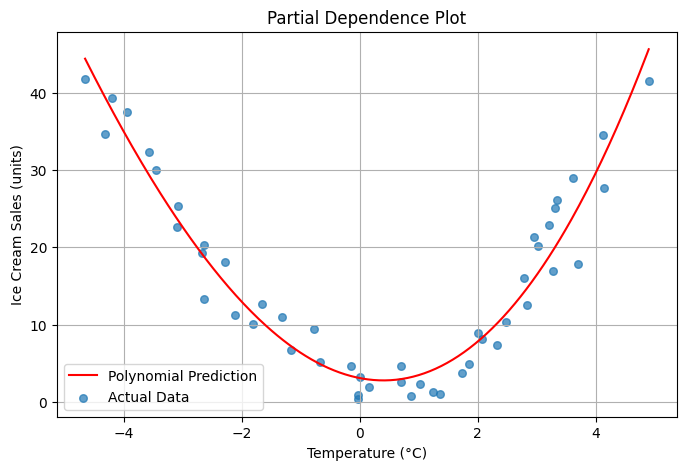

In [9]:
import matplotlib.pyplot as plt
import numpy as np

X_grid = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
X_grid_poly = poly.transform(X_grid)
y_grid_pred = model.predict(X_grid_poly)

plt.figure(figsize=(8, 5))
plt.plot(X_grid, y_grid_pred, color='red', label='Polynomial Prediction')
plt.scatter(X, y, s=30, alpha=0.7, label='Actual Data')
plt.xlabel(feature_col)
plt.ylabel(target_col)
plt.title('Partial Dependence Plot')
plt.legend()
plt.grid(True)
plt.show()


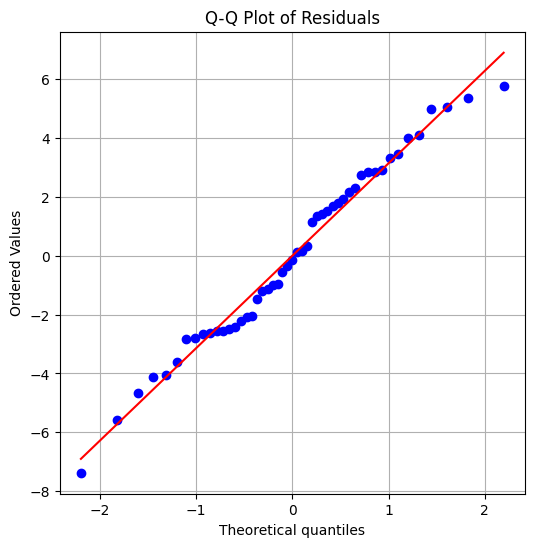

In [10]:
import scipy.stats as stats
import matplotlib.pyplot as plt

residuals = y - y_pred

plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.grid(True)
plt.show()


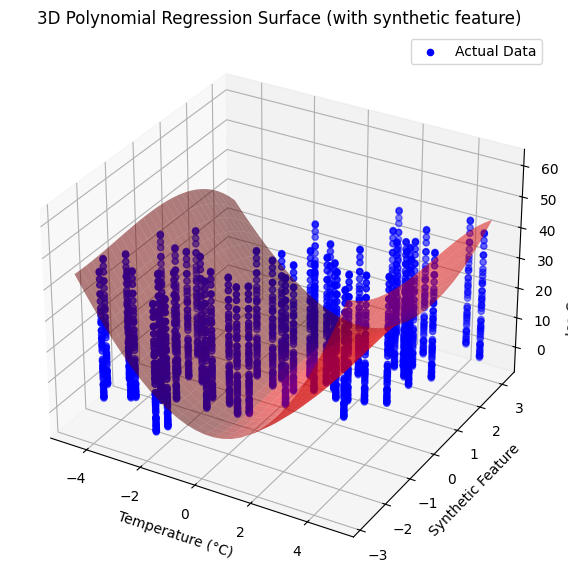

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Use your original data feature
X1 = data[["Temperature (°C)"]].values

# Create a synthetic second feature (e.g., random noise or some function)
np.random.seed(42)
X2 = (X1 * 0.5 + np.random.normal(0, 1, size=X1.shape)).reshape(-1, 1)

# Combine features
X_2d = np.hstack([X1, X2])

# Create polynomial features with degree 3
degree = 3
poly = PolynomialFeatures(degree=degree)
X_poly = poly.fit_transform(X_2d)

# Target stays the same
y = data["Ice Cream Sales (units)"].values

# Train model with 2 features
model = LinearRegression()
model.fit(X_poly, y)

# Prepare grid for plotting surface
x1_range = np.linspace(X1.min(), X1.max(), 30)
x2_range = np.linspace(X2.min(), X2.max(), 30)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)
grid_points = np.c_[x1_grid.ravel(), x2_grid.ravel()]
grid_poly = poly.transform(grid_points)
y_pred_grid = model.predict(grid_poly).reshape(x1_grid.shape)

# Plot 3D surface
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X1, X2, y, color='blue', label='Actual Data')
ax.plot_surface(x1_grid, x2_grid, y_pred_grid, color='red', alpha=0.5)
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Synthetic Feature')
ax.set_zlabel('Ice Cream Sales (units)')
plt.title('3D Polynomial Regression Surface (with synthetic feature)')
plt.legend()
plt.show()
